# PCA


## PCA From scratch


In [1]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()

X = iris.data


def PCA(X: list[list[float]], n_components: int) -> np.ndarray:

    X = np.array(X, dtype=float)

    X = X - np.mean(X, axis=0)

    cov = (X.T @ X) / (X.shape[0] - 1)

    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    idx = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    components = eigenvectors[:, :n_components]

    transformed = X @ components

    return transformed

In [3]:
X_transformed = PCA(X, 2)

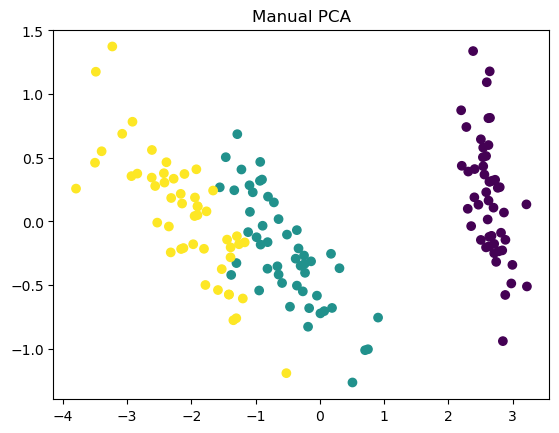

In [4]:
plt.scatter(x=X_transformed[:, 0], y=X_transformed[:, 1], c=iris.target)
plt.title("Manual PCA")
plt.show()

In [5]:
from sklearn.decomposition import PCA

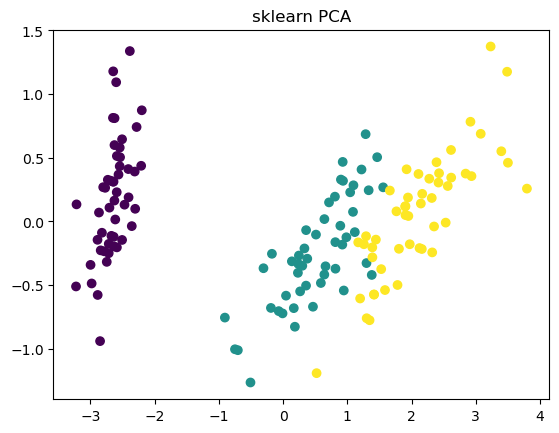

In [6]:
pca = PCA(n_components=2)
X_transformed = pca.fit_transform(X)
plt.scatter(x=X_transformed[:, 0], y=X_transformed[:, 1], c=iris.target)
plt.title("sklearn PCA")
plt.show()

# t-SNE


# SVD


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread

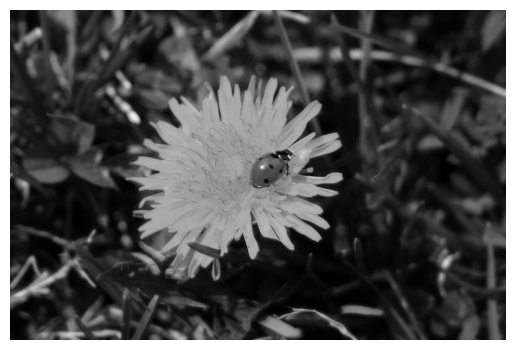

(533, 800, 3)

In [8]:
img = imread(
    r"C:\Users\USER\ipnyb files\Machine Learning\Unsupervised learning\images\clustering\ladybug.png"
)
X = np.mean(img, -1)

plt.imshow(X, cmap="gray")
plt.axis("off")
plt.show()

img.shape

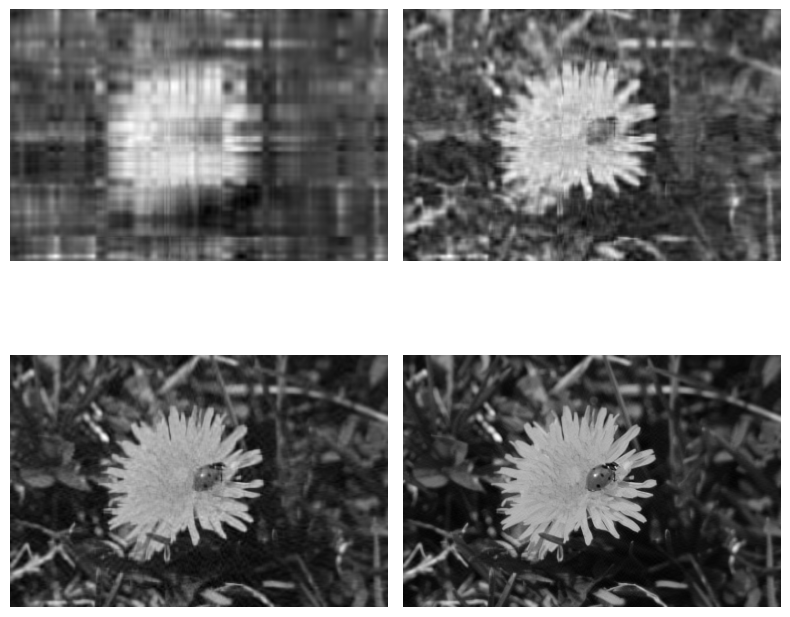

In [9]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)
S = np.diag(S)


j = 1
plt.figure(figsize=(8, 8))
for r in (5, 20, 50, 100):
    X_approax = U[:, :r] @ S[:r, :r] @ Vt[:r]

    plt.subplot(2, 2, j)
    plt.imshow(X_approax, cmap="gray")
    plt.axis("off")
    j += 1

plt.tight_layout()
plt.show()

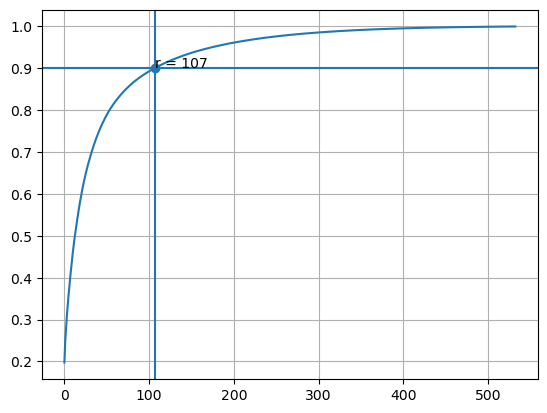

In [10]:
y = np.cumsum(np.diag(S)) / np.sum(np.diag(S))

threshold = 0.9

elbow_idx = np.where(y > threshold)[0][0]
elbow_val = y[elbow_idx]

plt.plot(y)
plt.axvline(elbow_idx)
plt.axhline(elbow_val)

plt.scatter(elbow_idx, elbow_val)

plt.text(elbow_idx, elbow_val, f"r = {elbow_idx}")

plt.grid(True)
plt.show()

# MNIST


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, trustworthiness

In [12]:
digits = load_digits()
X, y = digits.data, digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


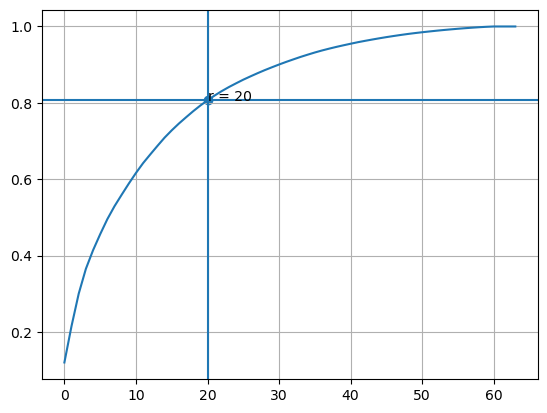

In [13]:
pca_full = PCA().fit(X_scaled)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

threshold = 0.8

elbow_idx = np.where(cum_variance > threshold)[0][0]
elbow_val = cum_variance[elbow_idx]

plt.plot(cum_variance)
plt.axvline(elbow_idx)
plt.axhline(elbow_val)
plt.text(elbow_idx, elbow_val, f"r = {elbow_idx}")
plt.scatter(elbow_idx, elbow_val)
plt.grid(True)
plt.show()

In [14]:
pca_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
svd_2d = TruncatedSVD(n_components=2, random_state=42).fit_transform(X_scaled)
tsne_low = TSNE(n_components=2, perplexity=2, random_state=42).fit_transform(X_scaled)
tsne_med = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
tsne_high = TSNE(n_components=2, perplexity=1000, random_state=42).fit_transform(
    X_scaled
)

In [15]:
# TruncatedSVD(n_components=2, random_state=42).fit(X_scaled)

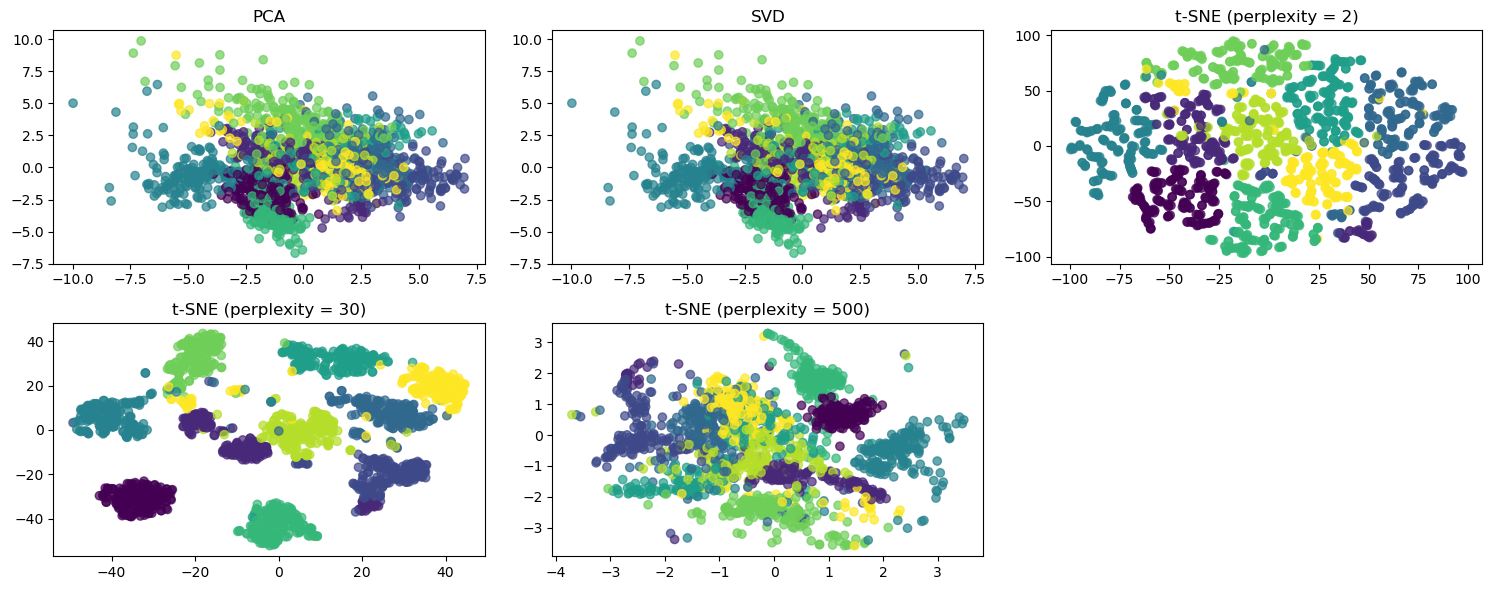

In [16]:
plt.figure(figsize=(15,6))

plt.subplot(231)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=y, alpha=0.7)
plt.title("PCA")

plt.subplot(232)
plt.scatter(svd_2d[:, 0], svd_2d[:, 1], c=y, alpha=0.7)
plt.title("SVD")

plt.subplot(233)
plt.scatter(tsne_low[:, 0], tsne_low[:, 1], c=y, alpha=0.7)
plt.title("t-SNE (perplexity = 2)")

plt.subplot(234)
plt.scatter(tsne_med[:, 0], tsne_med[:, 1], c=y, alpha=0.7)
plt.title("t-SNE (perplexity = 30)")

plt.subplot(235)
plt.scatter(tsne_high[:, 0], tsne_high[:, 1], c=y, alpha=0.7)
plt.title("t-SNE (perplexity = 500)")

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import mean_squared_error

pca_95 = PCA(n_components=0.95)
X_reduced = pca_95.fit_transform(X_scaled)
X_reconstructed = pca_95.inverse_transform(X_reduced)

mean_squared_error(X_scaled, X_reconstructed)

0.04691365839210275

In [24]:
len(pca_95.components_)

40

In [29]:
trustworthiness(X_scaled, tsne_med)

np.float64(0.9927938403021246)

# Review

In [36]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, trustworthiness
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [32]:
digits = load_digits()

X, y = digits.data, digits.target

X_scaled = StandardScaler().fit_transform(X)

In [33]:
best_score = 0
perplexity = 0
for p in range(30,50,2):
    tsne_transform = TSNE(n_components=2, perplexity=p, random_state=42).fit_transform(X_scaled)
    
    score = trustworthiness(X_scaled, tsne_transform)

    if score > best_score:
        best_score = score
        perplexity = p

In [34]:
f"Best Perplextity : {perplexity} | Score : {best_score}"

'Best Perplextity : 32 | Score : 0.9928665656971918'

In [35]:
tsne_2d = TSNE(n_components=2, perplexity=perplexity).fit_transform(X_scaled)
pca_2d = PCA(n_components=2).fit_transform(X_scaled)
svd_2d = TruncatedSVD(n_components=2).fit_transform(X_scaled)

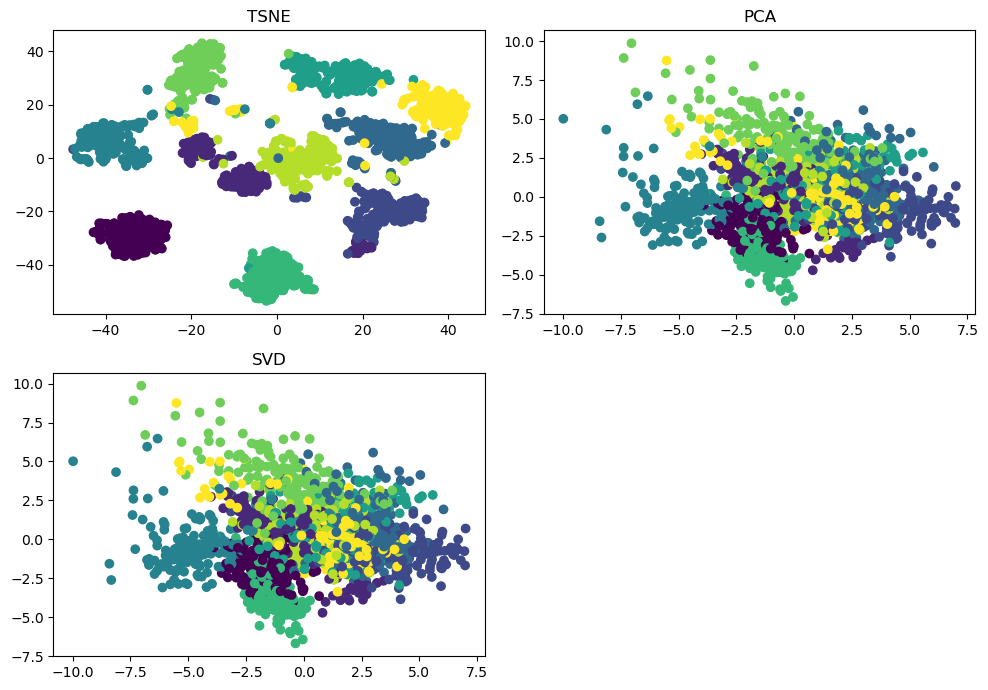

In [41]:
plt.figure(figsize=(10,7))

plt.subplot(221)
plt.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=y)
plt.title("TSNE")

plt.subplot(222)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=y)
plt.title("PCA")

plt.subplot(223)
plt.scatter(svd_2d[:, 0], svd_2d[:, 1], c=y)
plt.title("SVD")

plt.tight_layout()
plt.show()

In [ ]:
pca_model = PCA(n_components=0.95).fit(X_scaled)

In [45]:
len(pca_model.components_)

40

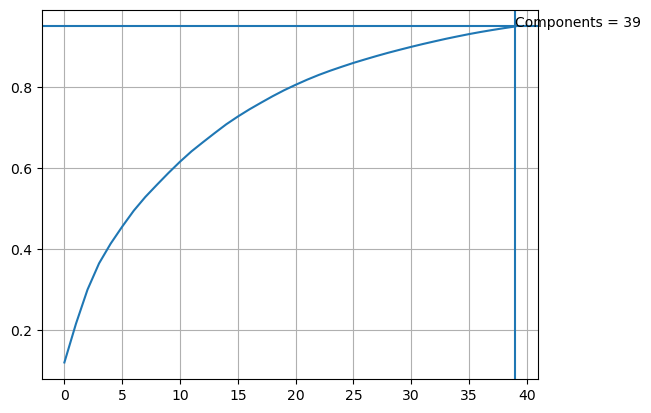

In [47]:
cum_sum = np.cumsum(pca_model.explained_variance_ratio_)

threshold = 0.95

elbow_idx = np.where(cum_sum > threshold)[0][0]
elbow_val = cum_sum[elbow_idx]

plt.plot(cum_sum)
plt.axvline(elbow_idx)
plt.axhline(elbow_val)
plt.text(elbow_idx, elbow_val, f"Components = {elbow_idx}")
plt.grid(True)
plt.show()
